In [ ]:
from functools import partial

import numpy as np

from configs import DETECTOR, N_NUMBERS
from core import (
    calculate_auc_score,
    run_experiment,
    show_experiment,
)
from emulations import generate_spectrum, EMULATION
from estimators import (
    create_matched_filter,
    estimate_by_amplitude,
    estimate_by_integral,
    estimate_by_template,
)


POSITION = N_NUMBERS // 2
CONCENTRATION = 1/(2 ** np.linspace(10, 3, 28+1))

In [2]:
unicorn = generate_spectrum(
    emulation=EMULATION,
    position=POSITION,
    concentration=1,
    is_noised=False,
    is_clipped=False,
)
template = unicorn.intensity[1,:]

matched_filter = create_matched_filter(
    template=template[::-1],
)

In [3]:
# estimators = {
#     # 'amplitude': partial(estimate_by_amplitude, position=POSITION),
#     # 'amplitude (matched filter)': partial(estimate_by_amplitude, position=POSITION, transformer=matched_filter),
#     # 'integral (1)': partial(estimate_by_integral, position=POSITION, interval=1),
#     'integral (2)': partial(estimate_by_integral, position=POSITION, interval=2),
#     # 'integral (3)': partial(estimate_by_integral, position=POSITION, interval=3),
# }
# fpr_intercept = [1e-1, 1e-2, 1e-3]
# auc_scores, fprs, tprs = run_experiment(
#     emulation=EMULATION,
#     position=POSITION,
#     concentration=CONCENTRATION,
#     estimators=estimators,
#     fpr_intercept=fpr_intercept,
# )

In [4]:
# intensity = CONCENTRATION * unicorn.intensity[1, POSITION]

# for key in [
#     # 'amplitude',
#     # 'amplitude (matched filter)',
#     'integral (2)',
# ]:
#     show_experiment(
#         intensity=intensity,
#         auc_score=auc_scores[key],
#         fpr=fprs[key],
#         tpr=tprs[key],
#         label=key,
#     )


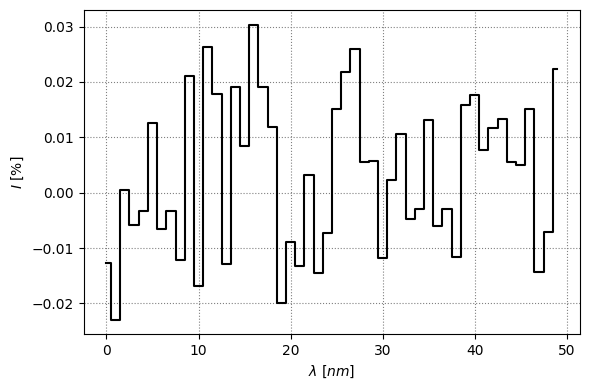

amplitude


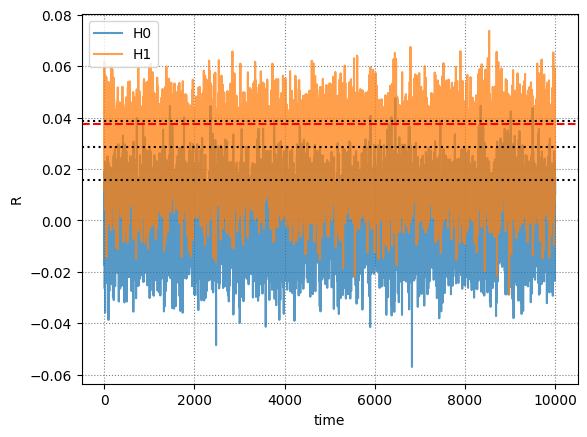

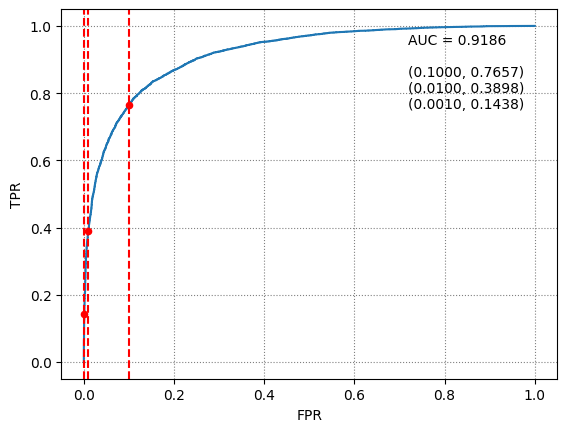

0.91858045 [0.1   0.01  0.001] [0.7657 0.3898 0.1438] [0.01572952 0.02853812 0.0388426 ]
matched filter


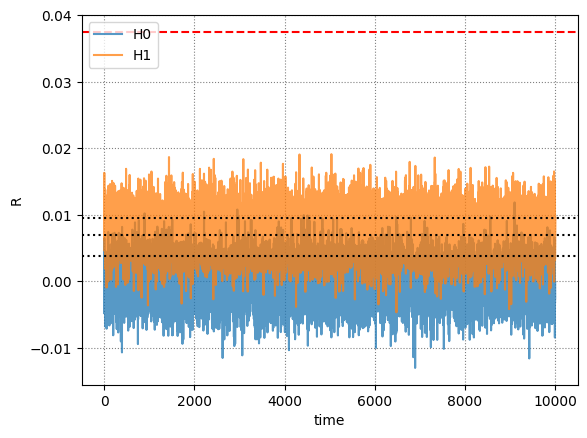

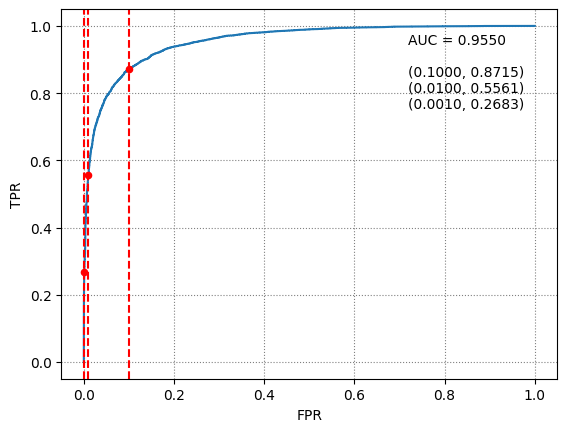

0.9550404399999999 [0.1   0.01  0.001] [0.8715 0.5561 0.2683] [0.00389679 0.00704108 0.00951486]
integral (2)


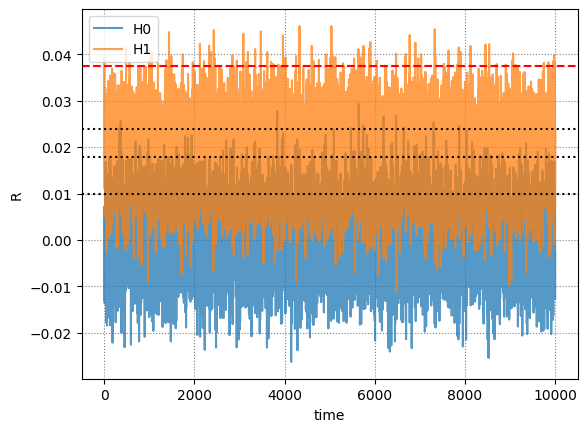

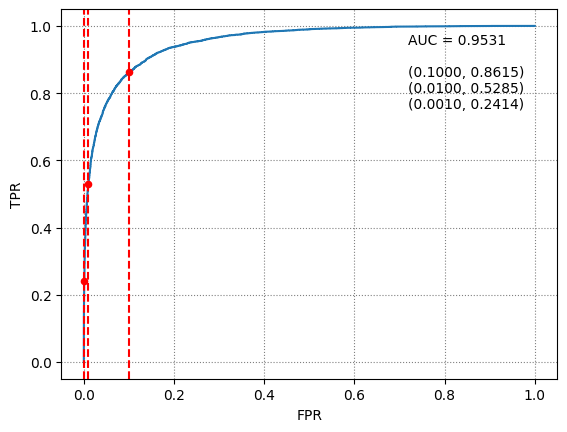

0.95308899 [0.1   0.01  0.001] [0.8615 0.5285 0.2414] [0.00985924 0.01779406 0.02397062]


In [ ]:
noise_read = 100 * DETECTOR.config.read_noise / DETECTOR.config.capacity
intensity = 2 * noise_read
concentration = intensity / unicorn.intensity[1, POSITION]

spectrum = generate_spectrum(
    emulation=EMULATION,
    position=POSITION,
    concentration=concentration,
)
spectrum[0].show()

for label, estimator in [
    ('amplitude', partial(estimate_by_amplitude, position=POSITION)),
    # ('amplitude (matched filter)', partial(estimate_by_amplitude, position=POSITION, transformer=matched_filter)),
    ('matched filter', partial(estimate_by_template, template=template)),
    # ('integral (1)', partial(estimate_by_integral, position=POSITION, interval=1)),
    ('integral (2)', partial(estimate_by_integral, position=POSITION, interval=2)),
    # ('integral (3)', partial(estimate_by_integral, position=POSITION, interval=3)),
    # ('integral (5)', partial(estimate_by_integral, position=POSITION, interval=5)),
]:

    score_h0 = estimator(
        spectrum=generate_spectrum(
            emulation=EMULATION,
            position=POSITION,
            concentration=0,
        ),
    )
    score_h1 = estimator(
        spectrum=spectrum,
    )

    print(label)

    auc_score, fpr, tpr, threshold = calculate_auc_score(
        score_h0=score_h0,
        score_h1=score_h1,
        fpr_intercept=[1e-1, 1e-2, 1e-3],
        show=True,
    )

    print(auc_score, fpr, tpr, threshold)
